# Assignment 2: Portfolio Optimization Using SCS

Aim - To solve the **long-only mean-variance problem** with **CVXPY + SCS** on two NIFTY-50 universes (Full: 49 stocks 2010–2021, Extended: 37 stocks 2004–2021), sweep $\gamma$ over six values to trace the efficient frontier, then quantify SCS's sensitivity to its tolerance/relaxation knobs and compare its solve time against ECOS and OSQP on the same problem.

Also refer to [README](README.md).


## Setup

In [1]:
from pathlib import Path

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

## Data and Universes

Two processed price matrices produced upstream by `data/Data_Pipeline.ipynb`:

- **Full universe** — `data/processed/price_matrix_full.csv`, 49 NIFTY-50 constituents with complete data from **2010-11-04 → 2021-04-30** (2,598 trading days).
- **Extended universe** — `data/processed/price_matrix_extended.csv`, 37 NIFTY-50 constituents with a longer history **2004-01-23 → 2021-04-30** (4,286 trading days). Stocks that did not trade across the longer window are dropped.

Both files store wide-format daily closing prices, one column per stock. The pseudo column `NIFTY50_all` is dropped before modelling. The upstream pipeline keeps only `Series == "EQ"` rows, removes pseudo symbols from `data/raw/raw_data.csv`, applies corporate-action winsorisation, and pivots long → wide.

In [2]:
DATA_DIR = None
for base in [Path.cwd(), *Path.cwd().parents]:
    candidate = base / "data" / "processed"
    if (candidate / "price_matrix_full.csv").exists():
        DATA_DIR = candidate
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not locate data/processed/price_matrix_full.csv from cwd or parents"
    )

In [3]:
def load_price_matrix(filename):
    df = pd.read_csv(DATA_DIR / filename, parse_dates=["Date"]).set_index("Date").sort_index()
    if "NIFTY50_all" in df.columns:
        df = df.drop(columns="NIFTY50_all")
    return df

In [4]:
price_matrix_full     = load_price_matrix("price_matrix_full.csv")
price_matrix_extended = load_price_matrix("price_matrix_extended.csv")

universe_summary = pd.DataFrame([
    {"Universe": "Full",     "Stocks": price_matrix_full.shape[1],
     "Days": price_matrix_full.shape[0],
     "Start": price_matrix_full.index.min().date(),
     "End":   price_matrix_full.index.max().date()},
    {"Universe": "Extended", "Stocks": price_matrix_extended.shape[1],
     "Days": price_matrix_extended.shape[0],
     "Start": price_matrix_extended.index.min().date(),
     "End":   price_matrix_extended.index.max().date()},
])
display(universe_summary)

,Universe,Stocks,Days,Start,End
0,Full,49,2598,2010-11-04,2021-04-30
1,Extended,37,4286,2004-01-23,2021-04-30


## Return and Risk Inputs

Daily simple returns $R_t = P_t / P_{t-1} - 1$. Annualise by the standard 252 factor:

$$\mu = 252 \, \mathbb E[R_t], \qquad \Sigma = 252 \, \mathrm{Cov}(R_t).$$

Sample-dependent, so Full and Extended give different $\mu$, $\Sigma$ — that's the whole point of the cross-universe comparison later.

In [5]:
def compute_annual_stats(matrix):
    returns = matrix.pct_change().dropna()
    mu      = returns.mean() * 252
    sigma   = returns.cov()  * 252
    return returns, mu, sigma

In [6]:
returns_full, mu_full, sigma_full = compute_annual_stats(price_matrix_full)
returns_ext,  mu_ext,  sigma_ext  = compute_annual_stats(price_matrix_extended)

stats_summary = pd.DataFrame([
    {"Universe": "Full",     "Assets": len(mu_full),
     "Average annual return":   mu_full.mean(),
     "Median annual return":    mu_full.median(),
     "Average annual volatility": np.mean(np.sqrt(np.diag(sigma_full.values)))},
    {"Universe": "Extended", "Assets": len(mu_ext),
     "Average annual return":   mu_ext.mean(),
     "Median annual return":    mu_ext.median(),
     "Average annual volatility": np.mean(np.sqrt(np.diag(sigma_ext.values)))},
])
display(stats_summary.style.format({
    "Average annual return":      "{:.2%}",
    "Median annual return":       "{:.2%}",
    "Average annual volatility":  "{:.2%}",
}))

,Universe,Assets,Average annual return,Median annual return,Average annual volatility
0,Full,49,11.59%,11.87%,35.99%
1,Extended,37,16.49%,15.60%,41.90%


In [7]:
asset_snapshot = pd.concat([
    pd.DataFrame({"mu_full":     mu_full,
                  "vol_full":    np.sqrt(np.diag(sigma_full.values))}),
    pd.DataFrame({"mu_extended": mu_ext,
                  "vol_extended": np.sqrt(np.diag(sigma_ext.values))}),
], axis=1)
display(asset_snapshot.head(10))

,mu_full,vol_full,mu_extended,vol_extended
ADANIPORTS,0.220366,0.383793,NaN,NaN
ASIANPAINT,0.165727,0.383418,0.237775,0.349627
AXISBANK,0.073667,0.447570,0.229381,0.473434
BAJAJ-AUTO,0.118709,0.262817,NaN,NaN
BAJAJFINSV,0.366879,0.354174,NaN,NaN
BAJFINANCE,0.390295,0.468532,0.424553,0.490940
BHARTIARTL,0.101996,0.328399,0.163086,0.386228
BPCL,0.053642,0.435283,0.097428,0.430795
BRITANNIA,0.259220,0.308058,0.184918,0.349687
CIPLA,0.128232,0.267090,0.088868,0.383311


## Global Minimum Variance Portfolio

Before sweeping $\gamma$, compute the lowest achievable portfolio risk on each universe — the GMV point. No $\gamma$-portfolio can sit below this floor.

$$\min_w \; w^\top \Sigma w \quad \text{s.t.} \quad \mathbf 1^\top w = 1, \;\; w \ge 0.$$

In [8]:
def gmv_risk(sigma):
    n = sigma.shape[0]
    w = cp.Variable(n)
    cp.Problem(
        cp.Minimize(cp.quad_form(w, sigma.values)),
        [cp.sum(w) == 1, w >= 0],
    ).solve(solver=cp.SCS, verbose=False, eps=1e-5, max_iters=20000)
    return float(np.sqrt(w.value @ sigma.values @ w.value))

In [9]:
gmv_full = gmv_risk(sigma_full)
gmv_ext  = gmv_risk(sigma_ext)
print(f"GMV risk floor Full universe:     {gmv_full:.4%}")
print(f"GMV risk floor Extended universe: {gmv_ext:.4%}")

GMV risk floor Full universe:     13.4255%
GMV risk floor Extended universe: 16.9968%


## SCS Solver

The mean-variance problem solved here:

$$\min_w \; \tfrac12 w^\top \Sigma w - \gamma \mu^\top w \quad \text{s.t.} \quad \mathbf 1^\top w = 1, \;\; w \ge 0.$$

SCS (Splitting Conic Solver) is a first-order operator-splitting solver. It needs a linear objective, so the quadratic term gets reformulated through Cholesky + a rotated second-order cone.

**Why Cholesky?** Factor $\Sigma = L L^\top$ once. Then $w^\top \Sigma w = \|L^\top w\|_2^2$, a squared norm SCS can express as a rotated SOC. $L$ depends only on $\Sigma$, not on $\gamma$ or $\mu$ — computed once, reused across every $\gamma$ and every ADMM iteration.

**Cone reformulation.** Introduce auxiliary $t$:

$$\min_{w, t} \; \tfrac12 t - \gamma \mu^\top w \quad \text{s.t.} \quad \|L^\top w\|_2^2 \le t, \;\; \mathbf 1^\top w = 1, \;\; w \ge 0.$$

Objective is linear in $(w, t)$; risk constraint is a rotated SOC. CVXPY passes this directly to SCS.

**ADMM iteration sketch.** Each SCS step:

1. **Primal solve** for $(w, t)$ ignoring cone:
   $$(w^{k+1}, t^{k+1}) = \arg\min_{w, t} \; \bigl(\tfrac12 t - \gamma \mu^\top w\bigr) + \tfrac{\rho}{2} \bigl\| (w, t) - z^k + u^k \bigr\|_2^2.$$
   Coefficient matrix involves $L^\top L = \Sigma$ — fixed across all $\gamma$, same factorisation reused.
2. **Cone projection** onto $\{\mathbf 1^\top w = 1\} \times \{w \ge 0\} \times \mathcal Q_{\text{rot}}$:
   $$z^{k+1} = \Pi\bigl(w^{k+1} + u^k, \; t^{k+1} + u_t^k\bigr).$$
3. **Dual ascent**:
   $$u^{k+1} = u^k + (w^{k+1}, t^{k+1}) - z^{k+1}.$$

Stop on primal + dual residual + duality gap below `eps`.

In [10]:
GAMMAS                = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
REPRESENTATIVE_GAMMAS = [0.1, 1.0, 5.0]
SOLVE_KWARGS          = {"solver": cp.SCS, "verbose": False, "eps": 1e-5, "max_iters": 20000}

The sweep helper builds the CVXPY problem once with $\gamma$ as a `cp.Parameter` so SCS can warm-start across the grid, runs the discrete `GAMMAS` for the table, then runs a dense 10k-point grid for a smooth frontier curve.

In [11]:
def run_scs_universe(matrix, gammas):
    returns, mu, sigma = compute_annual_stats(matrix)
    tickers  = returns.columns.tolist()
    n_assets = len(tickers)

    # parametrized problem — structure fixed, gamma varies
    w           = cp.Variable(n_assets)
    gamma_param = cp.Parameter(nonneg=True)
    prob = cp.Problem(
        cp.Minimize(0.5 * cp.quad_form(w, sigma.values) - gamma_param * (mu.values @ w)),
        [cp.sum(w) == 1, w >= 0],
    )

    rows, weights, statuses = [], {}, {}
    for g in gammas:
        gamma_param.value = float(g)
        prob.solve(**SOLVE_KWARGS)

        # clip solver noise + renormalise to exact simplex
        wt = np.clip(np.array(w.value).ravel(), 0, None)
        wt = wt / wt.sum()
        s  = pd.Series(wt, index=tickers)
        nz = s[s > 1e-4].sort_values(ascending=False)

        port_ret  = float(wt @ mu.values)
        port_risk = float(np.sqrt(wt @ sigma.values @ wt))
        rows.append({
            "Gamma":                      g,
            "Annualized Expected Return": port_ret,
            "Annualized Volatility":      port_risk,
            "Sharpe":                     port_ret / port_risk,
            "Stocks Selected":            int((wt > 1e-4).sum()),
            "Top Holdings":               ", ".join(f"{k}({v:.0%})" for k, v in nz.head(3).items()),
            "Status":                     prob.status,
        })
        weights[g]  = s.sort_values(ascending=False)
        statuses[g] = prob.status

    # dense frontier — 10k gamma values for smooth curve
    gamma_range = np.unique(np.concatenate([np.linspace(0.01, 10.0, 10000), np.array(gammas)]))
    frontier_returns, frontier_risks = [], []
    for g in gamma_range:
        gamma_param.value = float(g)
        prob.solve(**SOLVE_KWARGS)
        wt = np.clip(np.array(w.value).ravel(), 0, None)
        wt = wt / wt.sum()
        frontier_returns.append(float(wt @ mu.values))
        frontier_risks.append(float(np.sqrt(wt @ sigma.values @ wt)))

    return {
        "returns":  returns,
        "mu":       mu,
        "sigma":    sigma,
        "summary":  pd.DataFrame(rows),
        "weights":  weights,
        "frontier": pd.DataFrame({
            "Gamma":                      gamma_range,
            "Annualized Volatility":      frontier_risks,
            "Annualized Expected Return": frontier_returns,
        }),
        "tickers":  tickers,
    }

In [12]:
results_full     = run_scs_universe(price_matrix_full,     GAMMAS)
results_extended = run_scs_universe(price_matrix_extended, GAMMAS)

## Sector Mapping for Coloured Plots

Hand-coded ticker → sector dictionary covers every name in both universes. The 8-sector grouping (Finance, IT, Energy, FMCG, Auto, Pharma, etc.) drives the coloured scatter on the $\gamma$ panel plots below.

In [13]:
industry_map = {
    "NESTLEIND": "FMCG", "HINDUNILVR": "FMCG", "BRITANNIA": "FMCG", "ITC": "FMCG",
    "BAJAJFINSV": "Finance", "BAJFINANCE": "Finance", "HDFCBANK": "Finance", "ICICIBANK": "Finance",
    "KOTAKBANK": "Finance", "AXISBANK": "Finance", "SBIN": "Finance", "INDUSINDBK": "Finance", "HDFC": "Finance",
    "TITAN": "Consumer", "ASIANPAINT": "Consumer",
    "MARUTI": "Auto", "HEROMOTOCO": "Auto", "BAJAJ-AUTO": "Auto", "EICHERMOT": "Auto", "MM": "Auto", "TATAMOTORS": "Auto",
    "TCS": "IT", "INFY": "IT", "WIPRO": "IT", "HCLTECH": "IT", "TECHM": "IT",
    "RELIANCE": "Energy", "ONGC": "Energy", "BPCL": "Energy", "IOC": "Energy", "GAIL": "Energy",
    "POWERGRID": "Power", "NTPC": "Power", "COALINDIA": "Power",
    "TATASTEEL": "Metals", "HINDALCO": "Metals", "JSWSTEEL": "Metals", "VEDL": "Metals",
    "DRREDDY": "Pharma", "SUNPHARMA": "Pharma", "CIPLA": "Pharma",
    "ADANIPORTS": "Infra", "LT": "Infra", "GRASIM": "Infra",
    "ULTRACEMCO": "Cement", "SHREECEM": "Cement",
    "BHARTIARTL": "Telecom", "INFRATEL": "Telecom",
    "ZEEL": "Media", "UPL": "Agri",
}

industry_colors = {
    "FMCG": "#2ecc71", "Finance": "#3498db", "Consumer": "#9b59b6", "Auto": "#e74c3c",
    "IT": "#1abc9c", "Energy": "#f39c12", "Power": "#e67e22", "Metals": "#95a5a6",
    "Pharma": "#d35400", "Infra": "#8e44ad", "Cement": "#7f8c8d", "Telecom": "#16a085",
    "Media": "#c0392b", "Agri": "#27ae60", "Other": "#7f8c8d",
}

The 2×3 panel plot puts one $\gamma$ per subplot: smooth efficient frontier in red, all assets as grey points, selected assets in sector colour with ticker labels, optimal portfolio marked with an X.

In [14]:
def plot_gamma_panels(results, universe_label, panel_gammas=(0.1, 0.5, 1.0, 2.0, 5.0, 10.0)):
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    summary  = results["summary"].set_index("Gamma")
    tickers  = results["tickers"]
    mu       = results["mu"]
    sigma    = results["sigma"]
    frontier = results["frontier"]
    asset_vols = pd.Series(np.sqrt(np.diag(sigma.values)), index=tickers)

    fig, axes = plt.subplots(2, 3, figsize=(22, 13), sharex=True, sharey=True)
    axes = axes.ravel()

    xpad, ypad = 0.02, 0.03
    xmin = max(0, frontier["Annualized Volatility"].min() - xpad)
    xmax = frontier["Annualized Volatility"].max() + xpad
    ymin = frontier["Annualized Expected Return"].min() - ypad
    ymax = max(mu.max(), frontier["Annualized Expected Return"].max()) + ypad

    for ax, gamma in zip(axes, panel_gammas):
        row      = summary.loc[gamma]
        weights  = results["weights"][gamma]
        selected = weights[weights > 1e-4].sort_values(ascending=False)
        selected_names = set(selected.index)

        # unselected assets in grey
        for ticker in tickers:
            if ticker not in selected_names:
                ax.scatter(asset_vols[ticker], mu[ticker],
                           color="#d0d3d4", alpha=0.45, s=55, edgecolor="none", zorder=1)

        # selected assets coloured by sector + labelled
        for ticker in selected.index:
            industry = industry_map.get(ticker, "Other")
            color    = industry_colors.get(industry, industry_colors["Other"])
            ax.scatter(asset_vols[ticker], mu[ticker],
                       color=color, alpha=0.95, s=135, edgecolor="white", linewidth=1.4, zorder=4)
            ax.annotate(ticker, (asset_vols[ticker], mu[ticker]),
                        xytext=(5, 5), textcoords="offset points", fontsize=9, fontweight="bold")

        ax.plot(frontier["Annualized Volatility"], frontier["Annualized Expected Return"],
                color="red", linewidth=2.8, zorder=2)
        ax.scatter(row["Annualized Volatility"], row["Annualized Expected Return"],
                   marker="X", s=260, c="darkred", zorder=6, edgecolor="white", linewidth=1.8)
        ax.annotate(f"γ={gamma}",
                    (row["Annualized Volatility"], row["Annualized Expected Return"]),
                    xytext=(12, 12 if gamma >= 1.0 else 16),
                    textcoords="offset points", fontsize=12, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.28", facecolor="yellow", alpha=0.9))

        ax.set_title(f"γ = {gamma} Portfolio ({len(selected)} stocks)", fontsize=16, fontweight="bold")
        ax.grid(True, alpha=0.28, linestyle="--")
        ax.set_facecolor("#fafafa")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

        industries = [industry_map.get(t, "Other") for t in selected.index]
        unique = []
        for ind in industries:
            if ind not in unique:
                unique.append(ind)
        handles = [Patch(facecolor=industry_colors.get(ind, industry_colors["Other"]), label=ind) for ind in unique]
        handles.append(Line2D([0], [0], color="red", lw=2.8, label="Efficient Frontier"))
        ax.legend(handles=handles, loc="lower right", fontsize=9, title="Industry", frameon=True)

    for ax in axes[3:]:
        ax.set_xlabel("Annualized Risk (Volatility)", fontsize=11)
    for ax in axes[::3]:
        ax.set_ylabel("Annualized Expected Return", fontsize=11)

    fig.suptitle(f"{universe_label}: Gamma-by-Gamma Portfolio View", fontsize=20, fontweight="bold", y=0.98)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

## Full Universe γ Sweep

Six $\gamma$ values from aggressive diversification (γ=0.1) to return-dominant (γ=10). Table reports portfolio summary per γ; panel plot places each portfolio on the smooth efficient frontier.

In [15]:
summary_full = results_full["summary"].copy()
display(summary_full.style.format({
    "Annualized Expected Return": "{:.2%}",
    "Annualized Volatility":      "{:.2%}",
    "Sharpe":                     "{:.3f}",
}))

,Gamma,Annualized Expected Return,Annualized Volatility,Sharpe,Stocks Selected,Top Holdings,Status
0,0.100000,25.51%,16.73%,1.525,12,"HINDUNILVR(21%), SHREECEM(17%), BAJAJFINSV(15%)",optimal
1,0.500000,34.57%,26.77%,1.292,4,"BAJAJFINSV(45%), BAJFINANCE(24%), SHREECEM(23%)",optimal
2,1.000000,37.59%,33.66%,1.117,2,"BAJAJFINSV(62%), BAJFINANCE(38%)",optimal
3,2.000000,37.86%,34.83%,1.087,2,"BAJAJFINSV(50%), BAJFINANCE(50%)",optimal
4,5.000000,38.66%,42.16%,0.917,2,"BAJFINANCE(84%), BAJAJFINSV(16%)",optimal
5,10.000000,39.03%,46.85%,0.833,1,BAJFINANCE(100%),optimal


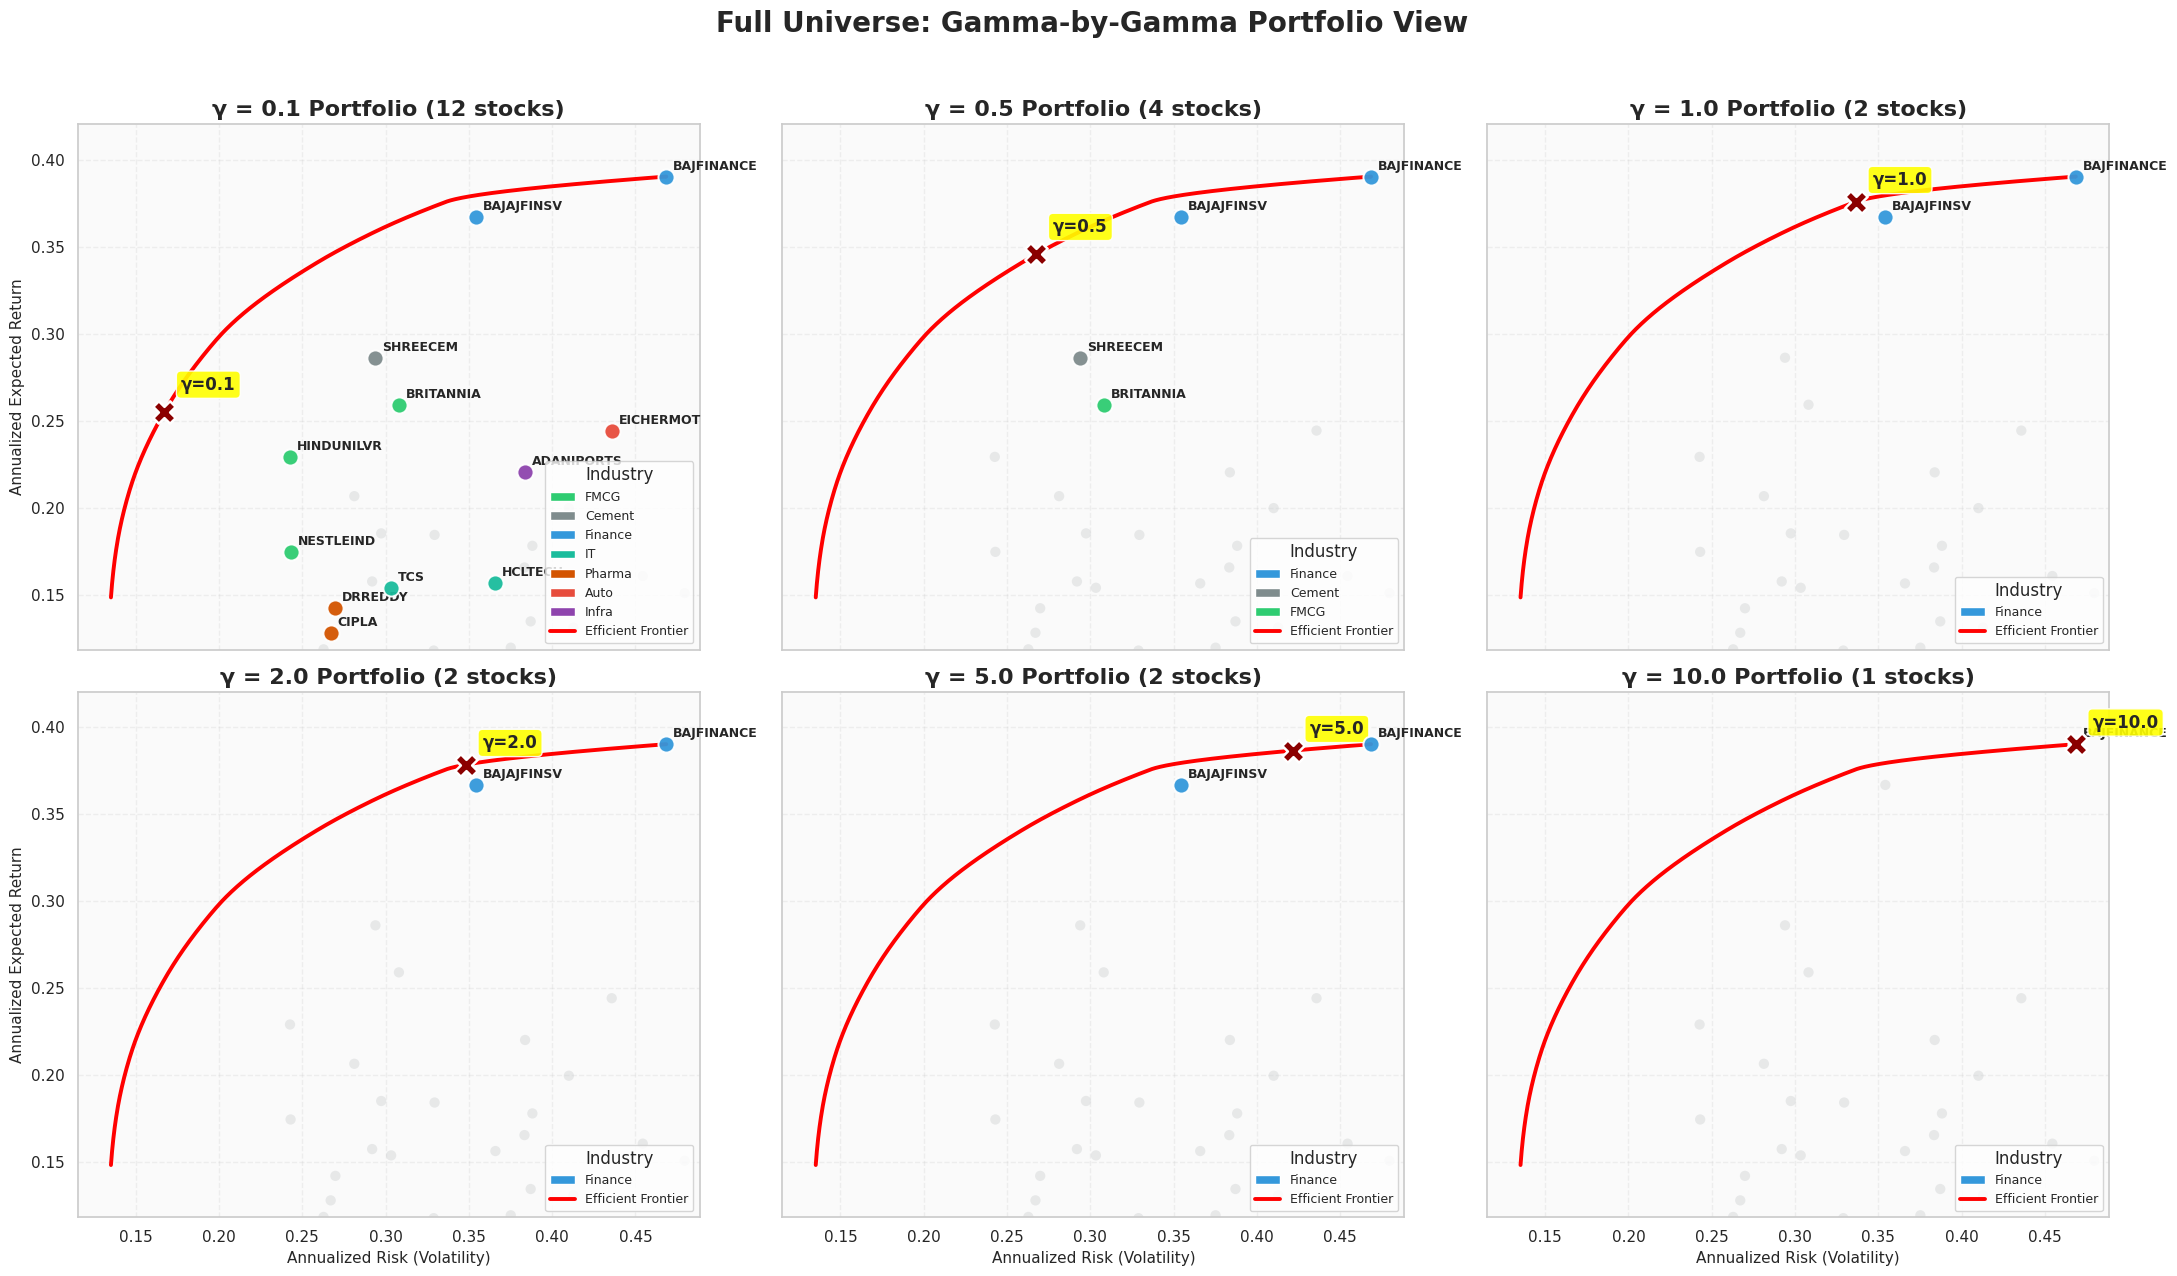

In [16]:
plot_gamma_panels(results_full, "Full Universe")

Weight table at three representative γ values shows the diversification → concentration transition asset-by-asset.

In [17]:
rep_weights_full = pd.concat(
    [results_full["weights"][g].rename(f"gamma={g}") for g in REPRESENTATIVE_GAMMAS],
    axis=1,
).fillna(0)
rep_weights_full = rep_weights_full.loc[(rep_weights_full > 1e-4).any(axis=1)]
rep_weights_full = rep_weights_full.sort_values(by=list(rep_weights_full.columns), ascending=False)
display(rep_weights_full.style.format("{:.2%}"))

,gamma=0.1,gamma=1.0,gamma=5.0
HINDUNILVR,21.25%,0.00%,0.00%
SHREECEM,17.48%,0.00%,0.00%
BAJAJFINSV,15.06%,61.57%,15.69%
BRITANNIA,11.87%,0.00%,0.00%
NESTLEIND,8.18%,0.00%,0.00%
TCS,6.47%,0.00%,0.00%
DRREDDY,6.27%,0.00%,0.00%
BAJFINANCE,6.00%,38.43%,84.31%
EICHERMOT,3.01%,0.00%,0.00%
CIPLA,2.29%,0.00%,0.00%


## Extended Universe γ Sweep

Same $\gamma$ grid on the longer-history Extended universe (37 stocks back to 2004). Compare against Full above to see how the 2008 crisis years change the estimated $(\mu, \Sigma)$ and therefore the preferred holdings.

In [18]:
summary_extended = results_extended["summary"].copy()
display(summary_extended.style.format({
    "Annualized Expected Return": "{:.2%}",
    "Annualized Volatility":      "{:.2%}",
    "Sharpe":                     "{:.3f}",
}))

,Gamma,Annualized Expected Return,Annualized Volatility,Sharpe,Stocks Selected,Top Holdings,Status
0,0.100000,27.44%,19.64%,1.397,12,"SHREECEM(23%), HINDUNILVR(13%), ASIANPAINT(13%)",optimal
1,0.500000,39.17%,29.70%,1.319,3,"SHREECEM(53%), BAJFINANCE(32%), TITAN(15%)",optimal
2,1.000000,39.87%,31.43%,1.269,3,"SHREECEM(52%), BAJFINANCE(43%), TITAN(6%)",optimal
3,2.000000,40.73%,35.04%,1.162,2,"BAJFINANCE(59%), SHREECEM(41%)",optimal
4,5.000000,42.45%,49.09%,0.865,1,BAJFINANCE(100%),optimal
5,10.000000,42.46%,49.09%,0.865,1,BAJFINANCE(100%),optimal


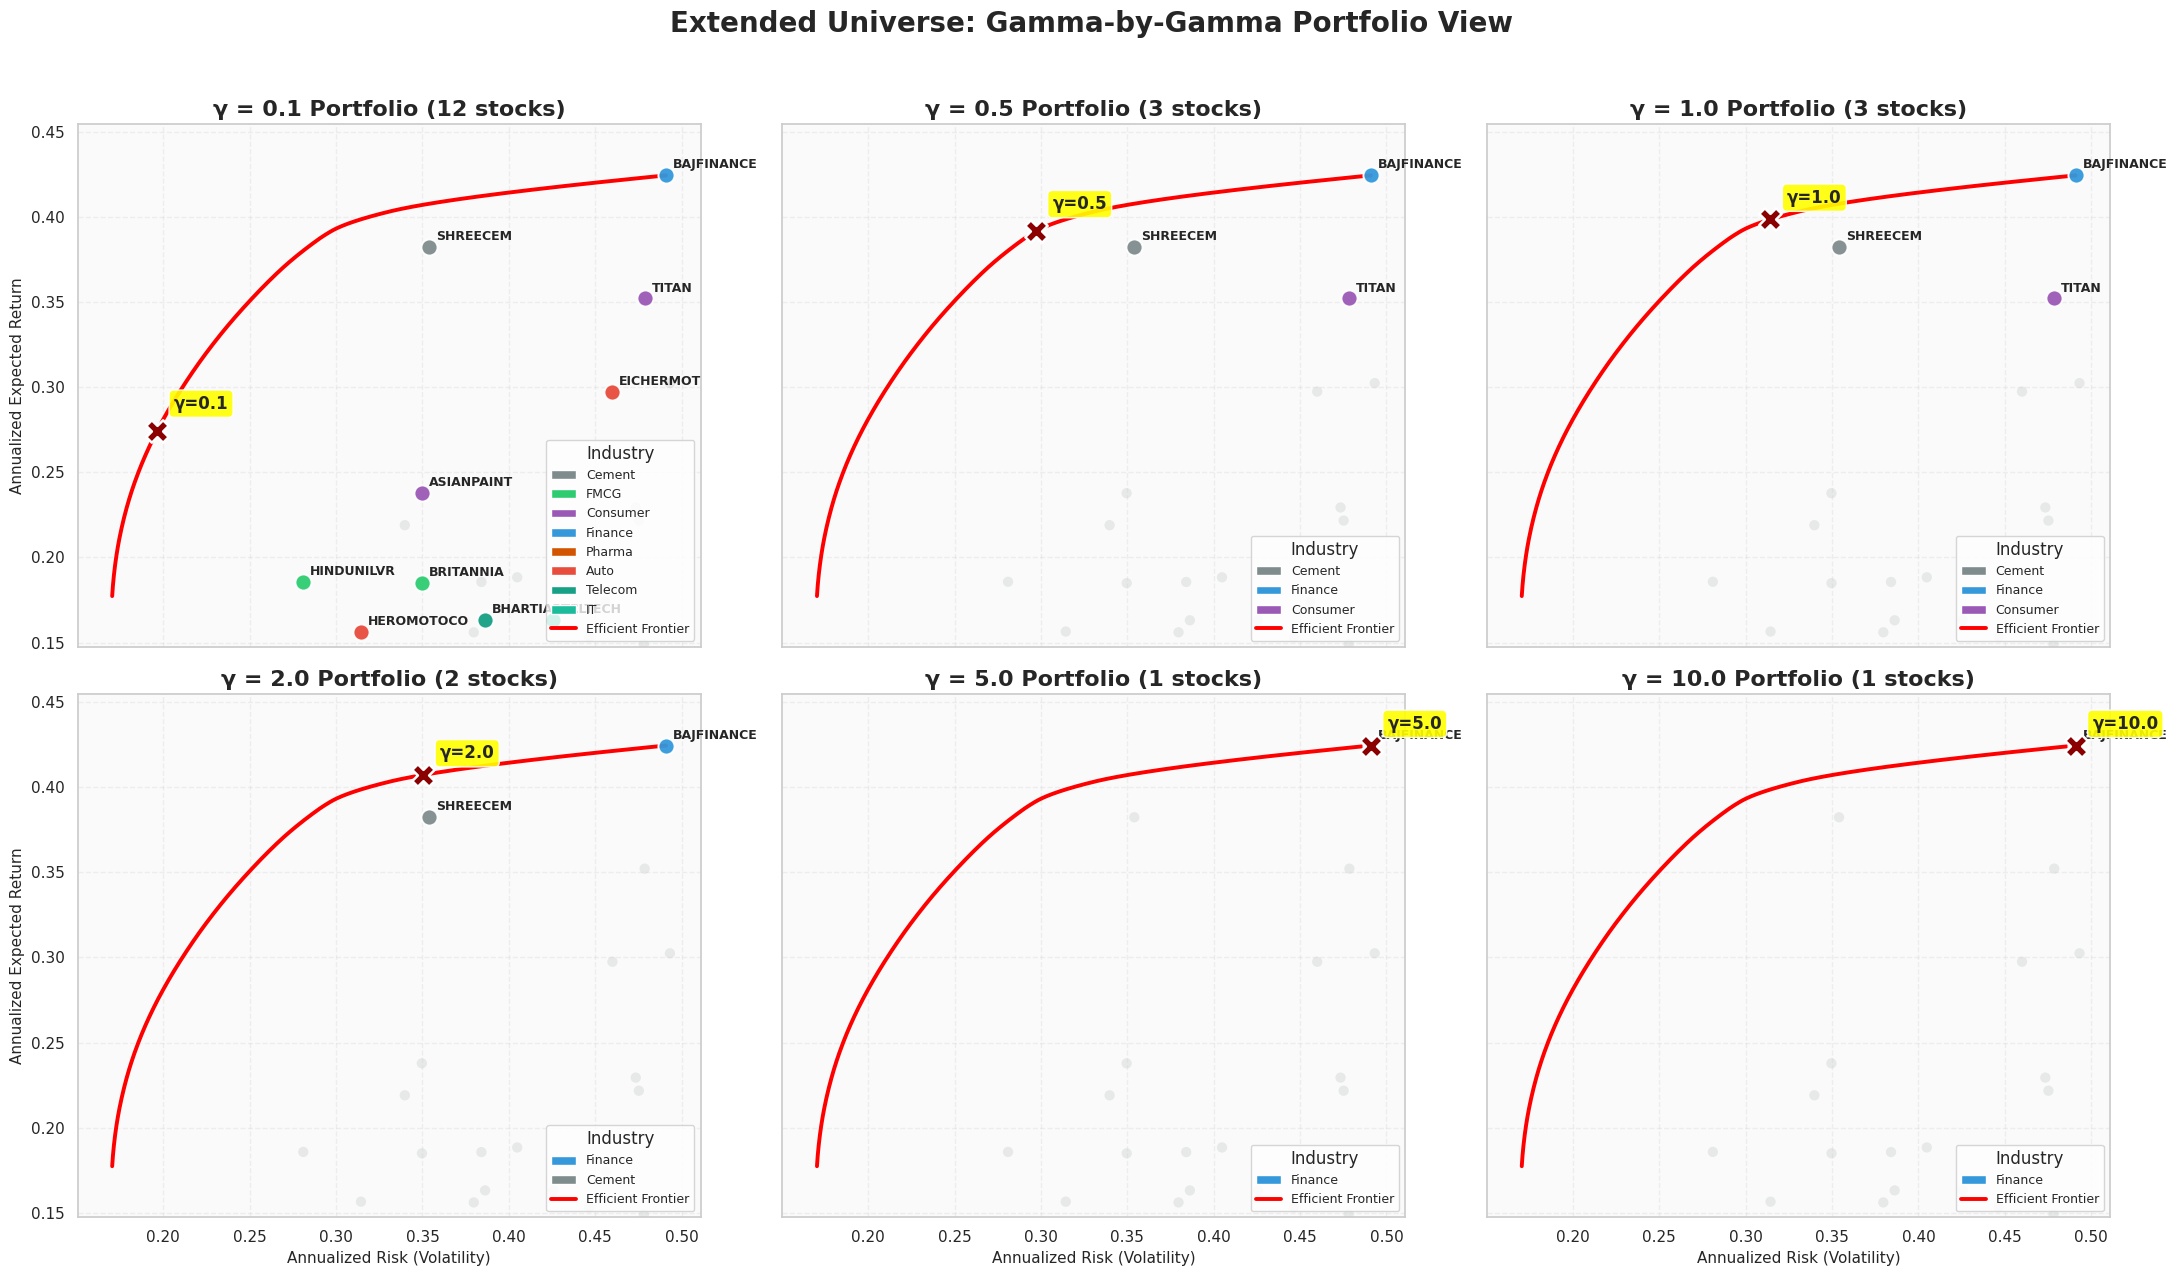

In [19]:
plot_gamma_panels(results_extended, "Extended Universe")

In [20]:
rep_weights_extended = pd.concat(
    [results_extended["weights"][g].rename(f"gamma={g}") for g in REPRESENTATIVE_GAMMAS],
    axis=1,
).fillna(0)
rep_weights_extended = rep_weights_extended.loc[(rep_weights_extended > 1e-4).any(axis=1)]
rep_weights_extended = rep_weights_extended.sort_values(by=list(rep_weights_extended.columns), ascending=False)
display(rep_weights_extended.style.format("{:.2%}"))

,gamma=0.1,gamma=1.0,gamma=5.0
SHREECEM,23.45%,51.62%,0.00%
HINDUNILVR,13.12%,0.00%,0.00%
ASIANPAINT,13.03%,0.00%,0.00%
BAJFINANCE,10.69%,42.75%,100.00%
BRITANNIA,10.69%,0.00%,0.00%
DRREDDY,7.33%,0.00%,0.00%
TITAN,6.85%,5.64%,0.00%
EICHERMOT,5.32%,0.00%,0.00%
HEROMOTOCO,4.36%,0.00%,0.00%
SUNPHARMA,2.47%,0.00%,0.00%


## Cross-Universe Comparison

Both universes solve the same SCS problem, so the difference comes entirely from the estimation sample. Comparison table puts every $\gamma$ row from both runs in one place.

In [21]:
comparison = pd.concat(
    [summary_full.assign(Universe="Full"),
     summary_extended.assign(Universe="Extended")],
    ignore_index=True,
)
display(
    comparison[["Universe", "Gamma", "Annualized Expected Return",
                "Annualized Volatility", "Sharpe", "Stocks Selected", "Top Holdings"]]
    .sort_values(["Universe", "Gamma"])
    .style.format({"Annualized Expected Return": "{:.2%}",
                   "Annualized Volatility":      "{:.2%}",
                   "Sharpe":                     "{:.3f}"})
)

,Universe,Gamma,Annualized Expected Return,Annualized Volatility,Sharpe,Stocks Selected,Top Holdings
6,Extended,0.100000,27.44%,19.64%,1.397,12,"SHREECEM(23%), HINDUNILVR(13%), ASIANPAINT(13%)"
7,Extended,0.500000,39.17%,29.70%,1.319,3,"SHREECEM(53%), BAJFINANCE(32%), TITAN(15%)"
8,Extended,1.000000,39.87%,31.43%,1.269,3,"SHREECEM(52%), BAJFINANCE(43%), TITAN(6%)"
9,Extended,2.000000,40.73%,35.04%,1.162,2,"BAJFINANCE(59%), SHREECEM(41%)"
10,Extended,5.000000,42.45%,49.09%,0.865,1,BAJFINANCE(100%)
11,Extended,10.000000,42.46%,49.09%,0.865,1,BAJFINANCE(100%)
0,Full,0.100000,25.51%,16.73%,1.525,12,"HINDUNILVR(21%), SHREECEM(17%), BAJAJFINSV(15%)"
1,Full,0.500000,34.57%,26.77%,1.292,4,"BAJAJFINSV(45%), BAJFINANCE(24%), SHREECEM(23%)"
2,Full,1.000000,37.59%,33.66%,1.117,2,"BAJAJFINSV(62%), BAJFINANCE(38%)"
3,Full,2.000000,37.86%,34.83%,1.087,2,"BAJAJFINSV(50%), BAJFINANCE(50%)"


Two side-by-side panels: Sharpe vs γ on the left, number of selected stocks vs γ on the right.

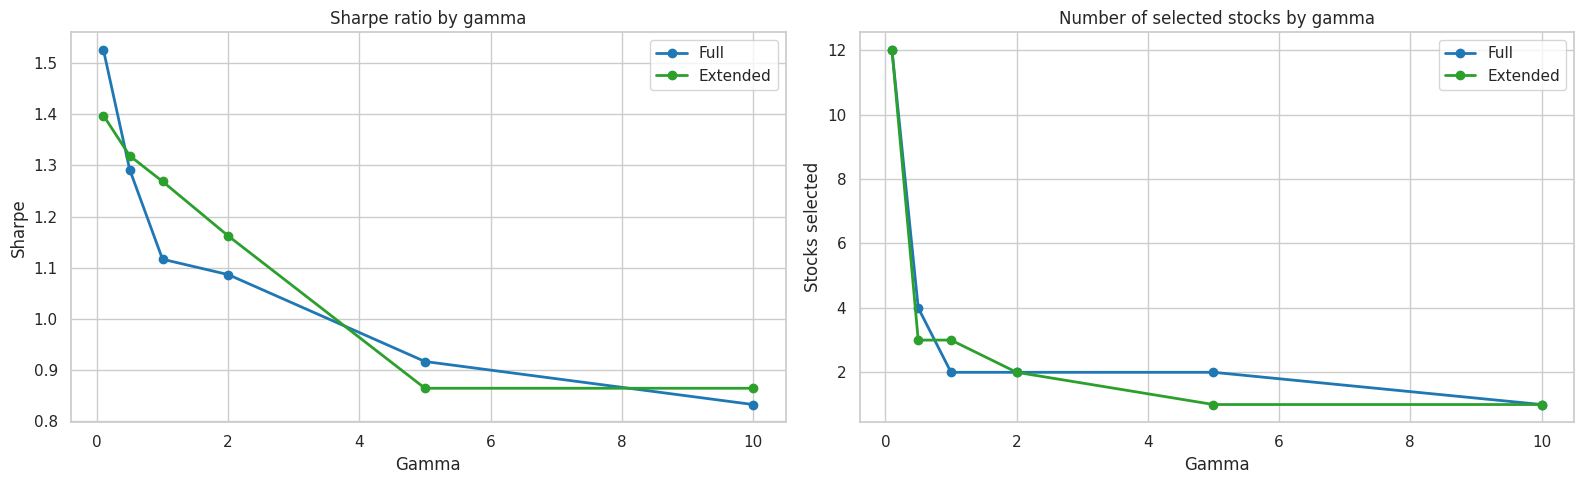

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for universe, color in [("Full", "#1F77B4"), ("Extended", "#2CA02C")]:
    sub = comparison[comparison["Universe"] == universe]
    axes[0].plot(sub["Gamma"], sub["Sharpe"],          marker="o", lw=2, label=universe, color=color)
    axes[1].plot(sub["Gamma"], sub["Stocks Selected"], marker="o", lw=2, label=universe, color=color)

axes[0].set_title("Sharpe ratio by gamma")
axes[0].set_xlabel("Gamma"); axes[0].set_ylabel("Sharpe"); axes[0].legend()
axes[1].set_title("Number of selected stocks by gamma")
axes[1].set_xlabel("Gamma"); axes[1].set_ylabel("Stocks selected"); axes[1].legend()
plt.tight_layout()
plt.show()

Smooth frontiers overlaid for direct shape + GMV-floor comparison.

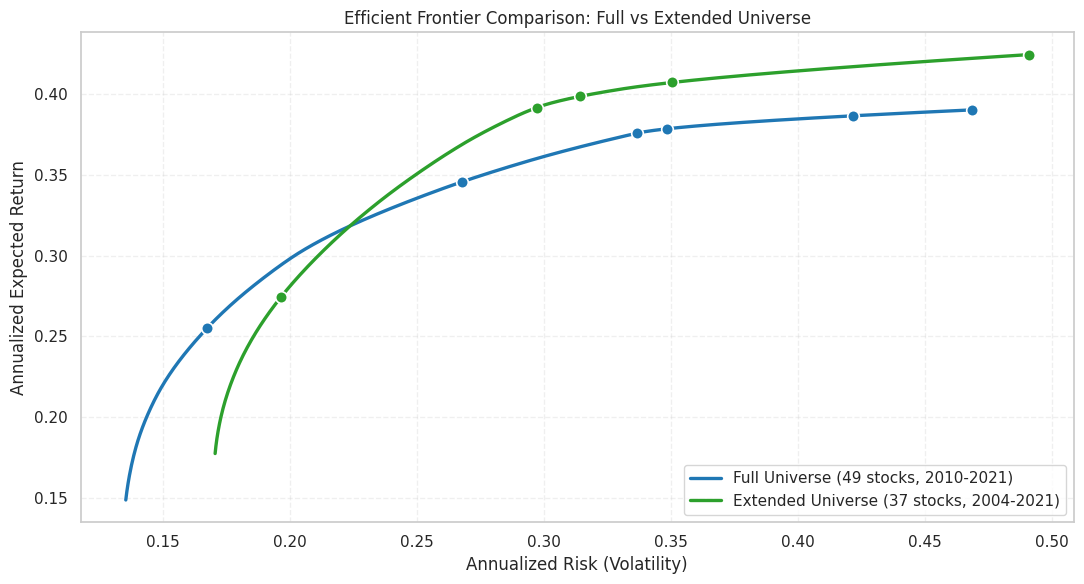

In [23]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(results_full["frontier"]["Annualized Volatility"],
        results_full["frontier"]["Annualized Expected Return"],
        color="#1F77B4", lw=2.4, label="Full Universe (49 stocks, 2010-2021)")
ax.plot(results_extended["frontier"]["Annualized Volatility"],
        results_extended["frontier"]["Annualized Expected Return"],
        color="#2CA02C", lw=2.4, label="Extended Universe (37 stocks, 2004-2021)")

for g in GAMMAS:
    rf = results_full["summary"].set_index("Gamma").loc[g]
    re = results_extended["summary"].set_index("Gamma").loc[g]
    ax.scatter(rf["Annualized Volatility"], rf["Annualized Expected Return"],
               color="#1F77B4", s=70, zorder=5, edgecolor="white", linewidth=1.2)
    ax.scatter(re["Annualized Volatility"], re["Annualized Expected Return"],
               color="#2CA02C", s=70, zorder=5, edgecolor="white", linewidth=1.2)

ax.set_xlabel("Annualized Risk (Volatility)")
ax.set_ylabel("Annualized Expected Return")
ax.set_title("Efficient Frontier Comparison: Full vs Extended Universe")
ax.legend(loc="lower right")
ax.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

## Solver Parameter Sensitivity

Hold the problem fixed at $\gamma = 1$ on the Full universe. Vary only SCS settings: tolerance `eps`, iteration cap `max_iters`, relaxation `alpha`. Question: do reasonable changes in solver knobs move the solution materially?

In [24]:
gamma_test = 1.0
returns    = results_full["returns"]
mu         = results_full["mu"]
sigma      = results_full["sigma"]
tickers    = results_full["tickers"]

w       = cp.Variable(len(tickers))
problem = cp.Problem(
    cp.Minimize(0.5 * cp.quad_form(w, sigma.values) - gamma_test * (mu.values @ w)),
    [cp.sum(w) == 1, w >= 0],
)

configs = [
    {"Config": "Standard",         "eps": 1e-4, "max_iters": 5000,  "alpha": 1.5},
    {"Config": "Loose",            "eps": 1e-3, "max_iters": 2500,  "alpha": 1.5},
    {"Config": "High Precision",   "eps": 1e-6, "max_iters": 20000, "alpha": 1.5},
    {"Config": "Aggressive Alpha", "eps": 1e-4, "max_iters": 5000,  "alpha": 1.8},
]

In [25]:
baseline = None
rows = []
for cfg in configs:
    problem.solve(solver=cp.SCS, verbose=False,
                  eps=cfg["eps"], max_iters=cfg["max_iters"], alpha=cfg["alpha"])
    wt = np.clip(np.array(w.value).ravel(), 0, None)
    wt = wt / wt.sum()
    port_ret  = float(wt @ mu.values)
    port_risk = float(np.sqrt(wt @ sigma.values @ wt))

    if baseline is None:
        baseline  = wt.copy()
        base_ret  = port_ret
        base_risk = port_risk

    rows.append({
        "Config":                          cfg["Config"],
        "Status":                          problem.status,
        "Annualized Expected Return":      port_ret,
        "Annualized Volatility":           port_risk,
        "Expected return drift vs standard": port_ret - base_ret,
        "Volatility drift vs standard":      port_risk - base_risk,
        "Weight drift (L2)":               float(np.linalg.norm(wt - baseline)),
        "Solve time (s)":                  problem.solver_stats.solve_time,
        "Iterations":                      getattr(problem.solver_stats, "num_iters", np.nan),
    })

sensitivity = pd.DataFrame(rows)
display(sensitivity.style.format({
    "Annualized Expected Return":         "{:.2%}",
    "Annualized Volatility":              "{:.2%}",
    "Expected return drift vs standard":  "{:+.4%}",
    "Volatility drift vs standard":       "{:+.4%}",
    "Weight drift (L2)":                  "{:.2e}",
    "Solve time (s)":                     "{:.6f}",
}))

,Config,Status,Annualized Expected Return,Annualized Volatility,Expected return drift vs standard,Volatility drift vs standard,Weight drift (L2),Solve time (s),Iterations
0,Standard,optimal,37.59%,33.66%,+0.0000%,+0.0000%,0.00e+00,0.000224,50
1,Loose,optimal,37.59%,33.66%,+0.0006%,+0.0003%,1.13e-05,0.000018,0
2,High Precision,optimal,37.59%,33.66%,+0.0007%,+0.0004%,1.46e-05,0.000120,25
3,Aggressive Alpha,optimal,37.59%,33.66%,+0.0007%,+0.0004%,1.47e-05,0.000017,0


## Solver Time Comparison

Same problem ($\gamma = 1$, Full universe) solved by SCS, a higher-precision SCS run, ECOS, and OSQP. Isolates wall-time cost across backends on a portfolio they all produce the same answer for.

In [26]:
solver_specs = [
    ("SCS",                  {"solver": cp.SCS,  "verbose": False, "eps": 1e-4, "max_iters": 5000}),
    ("SCS (High Precision)", {"solver": cp.SCS,  "verbose": False, "eps": 1e-6, "max_iters": 20000}),
    ("ECOS",                 {"solver": cp.ECOS, "verbose": False}),
    ("OSQP",                 {"solver": cp.OSQP, "verbose": False}),
]

solver_rows = []
for solver_name, solver_kwargs in solver_specs:
    w_cmp    = cp.Variable(len(tickers))
    prob_cmp = cp.Problem(
        cp.Minimize(0.5 * cp.quad_form(w_cmp, sigma.values) - gamma_test * (mu.values @ w_cmp)),
        [cp.sum(w_cmp) == 1, w_cmp >= 0],
    )
    prob_cmp.solve(**solver_kwargs)

    wt_cmp = np.clip(np.array(w_cmp.value).ravel(), 0, None)
    wt_cmp = wt_cmp / wt_cmp.sum()
    solver_rows.append({
        "Solver":                     solver_name,
        "Annualized Expected Return": float(wt_cmp @ mu.values),
        "Annualized Volatility":      float(np.sqrt(wt_cmp @ sigma.values @ wt_cmp)),
        "Solve time (s)":             prob_cmp.solver_stats.solve_time,
        "Iterations":                 getattr(prob_cmp.solver_stats, "num_iters", np.nan),
    })

runtime_compare = pd.DataFrame(solver_rows)
display(runtime_compare.style.format({
    "Annualized Expected Return": "{:.2%}",
    "Annualized Volatility":      "{:.2%}",
    "Solve time (s)":             "{:.6f}",
}))

,Solver,Annualized Expected Return,Annualized Volatility,Solve time (s),Iterations
0,SCS,37.59%,33.66%,0.000224,50
1,SCS (High Precision),37.59%,33.66%,0.000322,75
2,ECOS,37.59%,33.66%,0.002023,18
3,OSQP,37.59%,33.66%,0.001081,225


## Interpretation

Read these claims off the tables and plots above.

- **Diversification → concentration as $\gamma$ rises.** Both universes start with ~12 stocks across 7–8 sectors at $\gamma = 0.1$ and collapse to a 1–2 stock corner allocation by $\gamma \ge 5$, dominated by BAJFINANCE in both samples. Number-of-stocks vs $\gamma$ panel makes the transition explicit.
- **Estimation sample drives the holdings, not the solver.** Both universes solve the identical SCS problem. The Full universe (2010–2021) starts at a lower GMV risk floor (13.43% vs 16.99% for Extended) because it excludes the 2008 crisis. The Extended universe (2004–2021) has a steeper frontier slope because longer history captures the multi-year compounding of names like BAJFINANCE and SHREECEM. Crossover region is where universe breadth (49 names) loses to sample depth (17 years).
- **Sharpe peaks at $\gamma = 0.1$ on both universes.** Full Sharpe is highest at $\gamma = 0.1$ (1.525) and declines monotonically to 0.833 at $\gamma = 10$. Extended Sharpe also peaks at $\gamma = 0.1$ (1.397), then declines monotonically through 1.319, 1.269, 1.162 to 0.865 by $\gamma = 5$ — same direction as Full, with the steepest drop after $\gamma = 2$. The most concentrated end of the frontier is not the most Sharpe-efficient on either sample.
- **SCS is numerically stable.** Across `eps` ∈ {1e-3, 1e-4, 1e-6}, `max_iters` ∈ {2500, 5000, 20000}, and `alpha` ∈ {1.5, 1.8}, return drift ≤ +0.0007%, vol drift ≤ +0.0004%, and L2 weight drift ≤ 1.5e-05 — all $\sim 10^{-5}$ or smaller. The chosen knobs do not change the practical solution.
- **SCS beats ECOS and OSQP on wall time** for this problem class. Standard SCS (0.000224 s) is the fastest, then SCS High Precision (0.000322 s), OSQP (0.001081 s, ~5× SCS), then ECOS (0.002023 s, ~9× SCS), while all four land on the same portfolio (return 37.59%, vol 33.66%). The Cholesky-once-then-reuse pattern is the source — $L$ is independent of $\gamma$, so SCS amortises the linear-algebra cost across iterations.

## Limitations

- **Sample-dependent moments.** $\hat\mu$ and $\hat\Sigma$ are point estimates from historical returns. Out-of-sample performance is not addressed here; that's the walk-forward question in `04_nifty_application.ipynb` on the classical-baseline side.
- **No transaction costs or turnover penalty.** All reported Sharpe / volatility numbers are gross of friction.
- **Corner solutions at high $\gamma$.** The 1–2 stock allocations at $\gamma \ge 5$ are mathematically optimal under the model but operationally extreme. Adding a per-asset cap (e.g. $w_i \le 0.20$) is the standard fix; not enforced here.
- **No shorting or leverage.** All formulations enforce $w \ge 0$ and $\mathbf 1^\top w = 1$.
- **Solver-timing numbers are environment-dependent.** Wall times reflect this notebook's run; ranking is stable across runs but absolute numbers shift.